In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_main = pd.read_csv("/Users/romain/Desktop/Projets DS/ProjetStat/data/data_final/FINAL_GRAVITY_WITH_GDP.csv")





In [12]:
# 1. Nombre d'années différentes
nb_annees = df_main['year'].nunique()

# 2. Nombre total de lignes
nb_lignes = len(df_main)  # ou df_main.shape[0]

# 3. Nombre de codes ISO numériques différents (Origine)
nb_iso = df_main['iso_o'].nunique()

print(f"Années distinctes      : {nb_annees}")
print(f"Nombre total de lignes : {nb_lignes:,}")
print(f"Codes ISO uniques      : {nb_iso}")

# Bonus : Voir quelles sont les années disponibles
print("Liste des années :", df_main['year'].unique())

Années distinctes      : 6
Nombre total de lignes : 229,350
Codes ISO uniques      : 199
Liste des années : [1990 1995 2000 2005 2010 2015]


In [13]:
df_main.describe()

,iso_d,year,iso_o,flow,P_it,PSR_i,IMR_it,urban_it,LA_i,LL_i,...,gdpcap_o_lag,gdpcap_d_lag,log_gdp_o,log_gdp_d,log_gdpcap_o,log_gdpcap_d,log_gdp_o_lag,log_gdp_d_lag,log_gdpcap_o_lag,log_gdpcap_d_lag
count,229350.000000,229350.000000,229350.000000,2.293500e+05,2.193810e+05,219381.000000,219381.000000,213531.000000,2.193810e+05,219381.000000,...,194679.000000,194679.000000,197531.000000,197531.000000,197531.000000,197531.000000,194679.000000,194679.000000,194679.000000,194679.000000
mean,428.947874,2002.679398,428.947874,2.102040e+03,3.319251e+04,12.951796,0.034693,54.431490,6.937330e+05,0.191995,...,7.784657,7.784657,16.610729,16.610729,1.119418,1.119418,16.323423,16.323423,0.904292,0.904292
std,250.822573,8.557358,250.822573,2.636109e+04,1.284710e+05,9.464649,0.034103,23.280912,1.933117e+06,0.393870,...,12.459144,12.459144,2.382826,2.382826,1.609904,1.609904,2.398728,2.398728,1.600663,1.600663
min,4.000000,1990.000000,4.000000,0.000000e+00,6.215200e+01,2.344076,0.001258,5.274941,2.500000e+01,0.000000,...,0.065000,0.065000,10.254632,10.254632,-2.733368,-2.733368,9.966217,9.966217,-2.733368,-2.733368
25%,218.000000,1995.000000,218.000000,0.000000e+00,1.643333e+03,6.431519,0.008751,35.186618,2.633800e+04,0.000000,...,0.656000,0.656000,14.940920,14.940920,-0.229413,-0.229413,14.682408,14.682408,-0.421594,-0.421594
50%,422.000000,2005.000000,422.000000,0.000000e+00,6.418315e+03,12.487754,0.020929,55.199525,1.213200e+05,0.000000,...,2.262000,2.262000,16.385761,16.385761,1.083160,1.083160,16.066855,16.066855,0.816249,0.816249
75%,642.000000,2010.000000,642.000000,3.800000e+01,2.039835e+04,16.647862,0.053810,73.296231,5.470260e+05,0.000000,...,8.973000,8.973000,18.403049,18.403049,2.466658,2.466658,17.985463,17.985463,2.194220,2.194220
max,894.000000,2015.000000,894.000000,3.309139e+06,1.406848e+06,125.663414,0.225902,100.000000,1.707540e+07,1.000000,...,102.857000,102.857000,23.615672,23.615672,4.633340,4.633340,23.428940,23.428940,4.633340,4.633340


In [14]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229350 entries, 0 to 229349
Data columns (total 44 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   orig              229350 non-null  object 
 1   dest              229350 non-null  object 
 2   iso_d             229350 non-null  int64  
 3   year              229350 non-null  int64  
 4   iso_o             229350 non-null  int64  
 5   flow              229350 non-null  int64  
 6   P_it              219381 non-null  float64
 7   PSR_i             219381 non-null  float64
 8   IMR_it            219381 non-null  float64
 9   urban_it          213531 non-null  float64
 10  LA_i              219381 non-null  float64
 11  LL_i              219381 non-null  float64
 12  P_jt              219381 non-null  float64
 13  PSR_j             219381 non-null  float64
 14  IMR_jt            219381 non-null  float64
 15  urban_jt          213531 non-null  float64
 16  LA_j              21

In [15]:


# Nombre de pays uniques (en prenant l'union pour être sûr)
all_countries = set(df_main['orig'].unique()) | set(df_main['dest'].unique())
n = len(all_countries)

# Théorique par année (N * (N-1) si on exclut les flux vers soi-même)
theorie_annuelle = n * (n - 1)

print(f"Nombre de pays uniques : {n}")
print(f"Théorique par année : {theorie_annuelle} couples")

# Compte réel par année
coverage = df_main.groupby('year').size().to_frame('real_count')
coverage['theoretical'] = theorie_annuelle
coverage['pct_remplissage'] = (coverage['real_count'] / coverage['theoretical']) * 100

print("-" * 30)
print(coverage)

Nombre de pays uniques : 199
Théorique par année : 39402 couples
------------------------------
      real_count  theoretical  pct_remplissage
year                                          
1990       37442        39402        95.025633
1995       37442        39402        95.025633
2000       37442        39402        95.025633
2005       38220        39402        97.000152
2010       39402        39402       100.000000
2015       39402        39402       100.000000


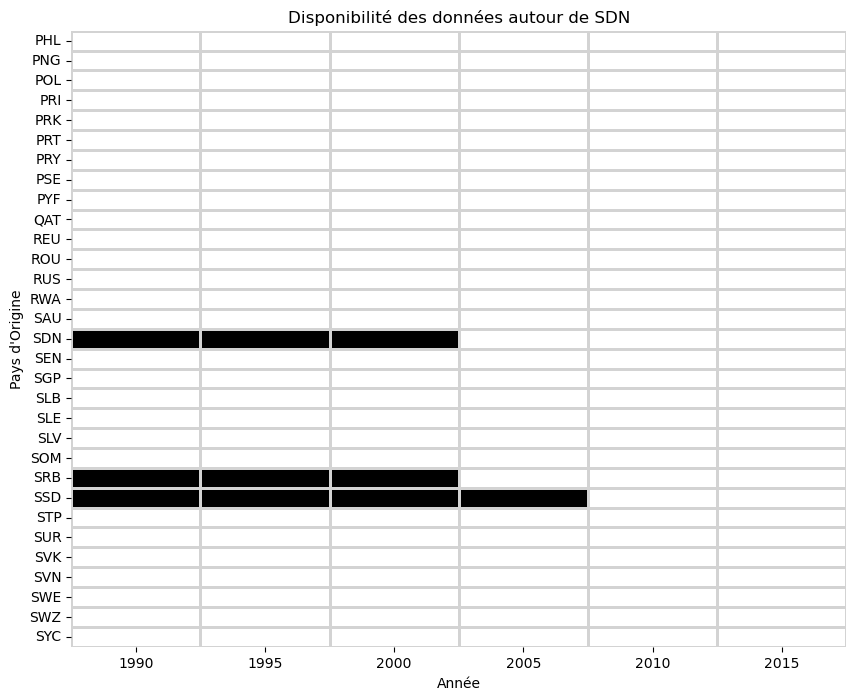

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TARGET_COUNTRY = 'SDN'
WINDOW = 15

# Sélection des pays
pays_uniques = sorted(df_main['orig'].unique())
idx = pays_uniques.index(TARGET_COUNTRY)
subset = pays_uniques[max(0, idx - WINDOW) : min(len(pays_uniques), idx + WINDOW + 1)]

# Filtrage et Matrice
df_zoom = df_main[df_main['orig'].isin(subset)]
presence = pd.crosstab(df_zoom['orig'], df_zoom['year'])

# Graphique
plt.figure(figsize=(10, 8))
sns.heatmap(presence > 0, cbar=False, cmap="binary_r", linewidths=1, linecolor='lightgray')
plt.title(f"Disponibilité des données autour de {TARGET_COUNTRY}")
plt.xlabel("Année")
plt.ylabel("Pays d'Origine")
plt.yticks(rotation=0)
plt.show()

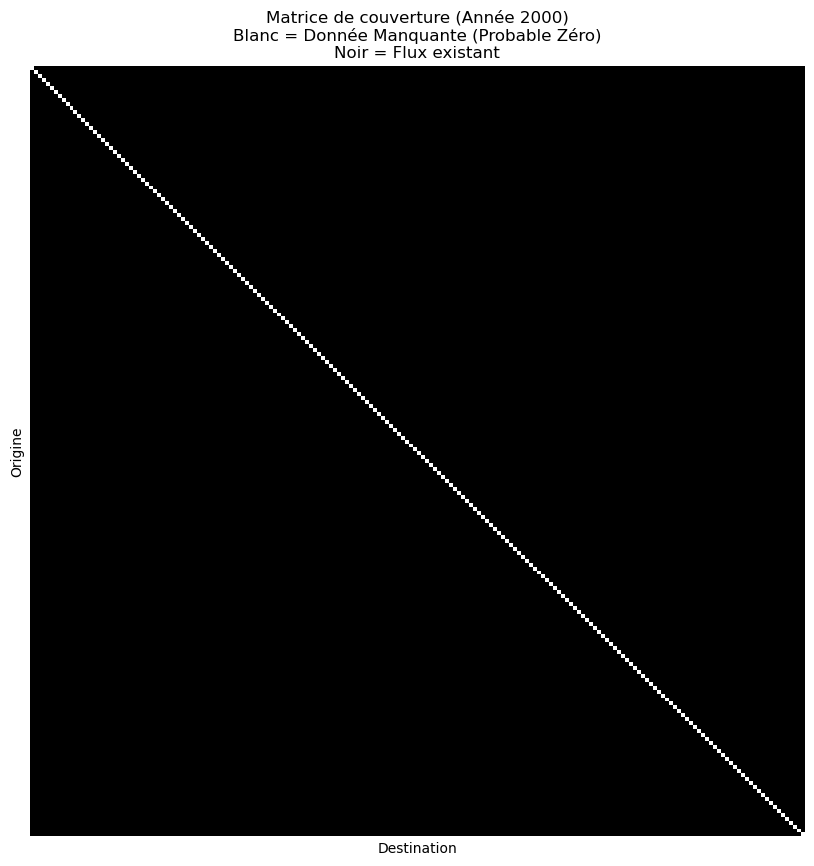

Taux de remplissage de la matrice en 2000 : 99.48%


In [23]:


# 1. On prend une année au milieu (2000)
df_2000 = df_main[df_main['year'] == 2000]

# 2. On crée la matrice Origine x Destination
# Si un couple existe, on met 1, sinon c'est vide (NaN)
matrix_2000 = df_2000.pivot(index='orig', columns='dest', values='flow')

# 3. On transforme en binaire pour le visuel : Présent vs Absent
# .notnull() va mettre True si la ligne existe, False si elle manque
sparsity = matrix_2000.notnull()

# 4. Le Graphique
plt.figure(figsize=(10, 10))
sns.heatmap(sparsity, cbar=False, cmap="binary", xticklabels=False, yticklabels=False)
plt.title("Matrice de couverture (Année 2000)\nBlanc = Donnée Manquante (Probable Zéro)\nNoir = Flux existant")
plt.xlabel("Destination")
plt.ylabel("Origine")
plt.show()

# 5. Calcul du taux de remplissage exact pour 2000
fill_rate = sparsity.sum().sum() / (sparsity.shape[0] * sparsity.shape[1])
print(f"Taux de remplissage de la matrice en 2000 : {fill_rate:.2%}")